# AQI Bucket Classification Training

This notebook trains machine learning models to classify AQI buckets based on air quality data from city_day.csv.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('city_day.csv')
print(df.head())
print(df.info())
print(df['AQI_Bucket'].value_counts())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  ----- 

In [3]:
# Data Preprocessing
# Drop unnecessary columns
df = df.drop(['City', 'Date'], axis=1)  # Keep AQI

# Handle missing values - fill with mean for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# Drop rows with missing AQI_Bucket
df = df.dropna(subset=['AQI_Bucket'])

# Correct AQI_Bucket based on AQI values
def get_bucket_from_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df['AQI_Bucket'] = df['AQI'].apply(get_bucket_from_aqi)

# Encode the target variable
le = LabelEncoder()
df['AQI_Bucket'] = le.fit_transform(df['AQI_Bucket'])

# Features and target
X = df.drop('AQI_Bucket', axis=1)
y = df['AQI_Bucket']

print("Classes:", le.classes_)
print("Shape:", X.shape, y.shape)

Classes: ['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']
Shape: (24850, 13) (24850,)


In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, target_names=le.classes_))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       268
    Moderate       1.00      1.00      1.00      1766
        Poor       1.00      1.00      1.00       556
Satisfactory       1.00      1.00      1.00      1645
      Severe       1.00      1.00      1.00       268
   Very Poor       1.00      1.00      1.00       467

    accuracy                           1.00      4970
   macro avg       1.00      1.00      1.00      4970
weighted avg       1.00      1.00      1.00      4970



In [6]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred, target_names=le.classes_))

Logistic Regression Accuracy: 0.9569416498993963
              precision    recall  f1-score   support

        Good       0.99      0.75      0.85       268
    Moderate       0.97      0.97      0.97      1766
        Poor       0.98      0.94      0.96       556
Satisfactory       0.94      0.98      0.96      1645
      Severe       0.99      0.93      0.96       268
   Very Poor       0.93      0.98      0.96       467

    accuracy                           0.96      4970
   macro avg       0.97      0.92      0.94      4970
weighted avg       0.96      0.96      0.96      4970



In [7]:
# Train SVM
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, target_names=le.classes_))

SVM Accuracy: 0.938430583501006
              precision    recall  f1-score   support

        Good       0.97      0.70      0.81       268
    Moderate       0.95      0.97      0.96      1766
        Poor       0.96      0.92      0.94       556
Satisfactory       0.93      0.96      0.94      1645
      Severe       0.92      0.91      0.92       268
   Very Poor       0.90      0.94      0.92       467

    accuracy                           0.94      4970
   macro avg       0.94      0.90      0.91      4970
weighted avg       0.94      0.94      0.94      4970



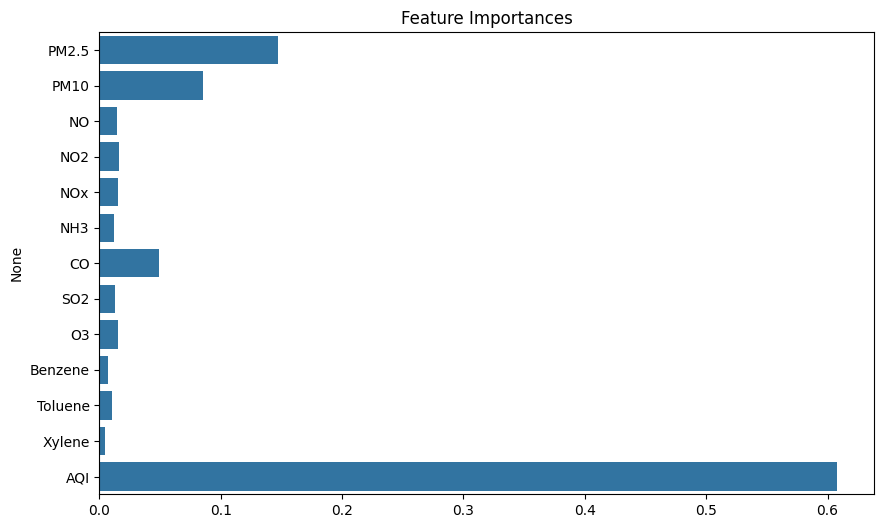

In [8]:
# Feature Importance from Random Forest
importances = rf_model.feature_importances_
features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importances')
plt.show()

In [9]:
# Check AQI ranges for each bucket
print("AQI ranges for each bucket:")
for bucket in df['AQI_Bucket'].unique():
    subset = df[df['AQI_Bucket'] == bucket]
    print(f"{le.inverse_transform([bucket])[0]}: AQI min={subset['AQI'].min():.1f}, max={subset['AQI'].max():.1f}, mean={subset['AQI'].mean():.1f}")

# Check if AQI determines bucket perfectly
def get_bucket_from_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df['calculated_bucket'] = df['AQI'].apply(get_bucket_from_aqi)
print("\nMismatch count:", (df['calculated_bucket'] != le.inverse_transform(df['AQI_Bucket'])).sum())

AQI ranges for each bucket:
Poor: AQI min=201.0, max=300.0, mean=245.7
Very Poor: AQI min=301.0, max=400.0, mean=343.0
Severe: AQI min=401.0, max=2049.0, mean=567.9
Moderate: AQI min=101.0, max=200.0, mean=136.7
Satisfactory: AQI min=51.0, max=100.0, mean=76.8
Good: AQI min=13.0, max=50.0, mean=40.3

Mismatch count: 0


In [10]:
# Save the trained model, scaler, and label encoder
import joblib

# Save Random Forest model (best performing)
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model, scaler, and label encoder saved successfully!")

Model, scaler, and label encoder saved successfully!


In [11]:
# Load the saved model, scaler, and label encoder
loaded_rf_model = joblib.load('rf_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_le = joblib.load('label_encoder.pkl')

print("Model, scaler, and label encoder loaded successfully!")

# Take inference on test data
# Scale the test data using loaded scaler
X_test_scaled_loaded = loaded_scaler.transform(X_test)

# Make predictions
predictions = loaded_rf_model.predict(X_test_scaled_loaded)

# Convert predictions back to original labels
predicted_labels = loaded_le.inverse_transform(predictions)

# Display some predictions
print("\nSample predictions on test data:")
for i in range(10):
    print(f"Predicted: {predicted_labels[i]}, Actual: {loaded_le.inverse_transform([y_test.iloc[i]])[0]}")

# Calculate accuracy on loaded model
from sklearn.metrics import accuracy_score
loaded_accuracy = accuracy_score(y_test, predictions)
print(f"\nLoaded model accuracy on test data: {loaded_accuracy:.4f}")

# Classification report
from sklearn.metrics import classification_report
print("\nClassification Report for Loaded Model:")
print(classification_report(y_test, predictions, target_names=loaded_le.classes_))

Model, scaler, and label encoder loaded successfully!

Sample predictions on test data:
Predicted: Satisfactory, Actual: Satisfactory
Predicted: Moderate, Actual: Moderate
Predicted: Satisfactory, Actual: Satisfactory
Predicted: Moderate, Actual: Moderate
Predicted: Severe, Actual: Severe
Predicted: Moderate, Actual: Moderate
Predicted: Satisfactory, Actual: Satisfactory
Predicted: Satisfactory, Actual: Satisfactory
Predicted: Moderate, Actual: Moderate
Predicted: Moderate, Actual: Moderate

Loaded model accuracy on test data: 1.0000

Classification Report for Loaded Model:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       268
    Moderate       1.00      1.00      1.00      1766
        Poor       1.00      1.00      1.00       556
Satisfactory       1.00      1.00      1.00      1645
      Severe       1.00      1.00      1.00       268
   Very Poor       1.00      1.00      1.00       467

    accuracy                           

In [12]:
# AQI Regression Model Training
# Import regression libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare data for regression (predict AQI value)
# Features are the pollutants, target is AQI
X_reg = df.drop(['AQI', 'AQI_Bucket', 'calculated_bucket'], axis=1, errors='ignore')  # Drop AQI and bucket columns
y_reg = df['AQI']

print("Regression Features:", X_reg.columns.tolist())
print("Target: AQI")
print("Data shape:", X_reg.shape, y_reg.shape)

# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale the features
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

Regression Features: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
Target: AQI
Data shape: (24850, 12) (24850,)


In [13]:
# Train Random Forest Regressor
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_model.fit(X_train_reg_scaled, y_train_reg)
rf_reg_pred = rf_reg_model.predict(X_test_reg_scaled)

print("Random Forest Regressor Results:")
print(f"MAE: {mean_absolute_error(y_test_reg, rf_reg_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test_reg, rf_reg_pred):.2f}")
print(f"RMSE: {mean_squared_error(y_test_reg, rf_reg_pred, squared=False):.2f}")
print(f"R² Score: {r2_score(y_test_reg, rf_reg_pred):.4f}")

# Train Linear Regression
lr_reg_model = LinearRegression()
lr_reg_model.fit(X_train_reg_scaled, y_train_reg)
lr_reg_pred = lr_reg_model.predict(X_test_reg_scaled)

print("\nLinear Regression Results:")
print(f"MAE: {mean_absolute_error(y_test_reg, lr_reg_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test_reg, lr_reg_pred):.2f}")
print(f"RMSE: {mean_squared_error(y_test_reg, lr_reg_pred, squared=False):.2f}")
print(f"R² Score: {r2_score(y_test_reg, lr_reg_pred):.4f}")

# Train SVR
svr_reg_model = SVR(kernel='rbf')
svr_reg_model.fit(X_train_reg_scaled, y_train_reg)
svr_reg_pred = svr_reg_model.predict(X_test_reg_scaled)

print("\nSVR Results:")
print(f"MAE: {mean_absolute_error(y_test_reg, svr_reg_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test_reg, svr_reg_pred):.2f}")
print(f"RMSE: {mean_squared_error(y_test_reg, svr_reg_pred, squared=False):.2f}")
print(f"R² Score: {r2_score(y_test_reg, svr_reg_pred):.4f}")

Random Forest Regressor Results:
MAE: 20.74
MSE: 1664.36
RMSE: 40.80
R² Score: 0.9091

Linear Regression Results:
MAE: 31.20
MSE: 3493.79
RMSE: 59.11
R² Score: 0.8092


c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



SVR Results:
MAE: 34.30
MSE: 6309.18
RMSE: 79.43
R² Score: 0.6554


c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [14]:
# Save the best regression model (Random Forest Regressor)
joblib.dump(rf_reg_model, 'rf_reg_model.pkl')
joblib.dump(scaler_reg, 'scaler_reg.pkl')

print("Regression model and scaler saved successfully!")

Regression model and scaler saved successfully!


In [26]:
# Filter test data by AQI buckets for regression model testing
import pandas as pd

# Load the original dataset
df_full = pd.read_csv('city_day.csv')

# Handle missing values - fill with mean for numerical columns
numerical_cols = df_full.select_dtypes(include=[np.number]).columns
df_full[numerical_cols] = df_full[numerical_cols].fillna(df_full[numerical_cols].mean())

# Drop rows with missing AQI_Bucket
df_full = df_full.dropna(subset=['AQI_Bucket'])

# Correct AQI_Bucket based on AQI values (same function as before)
def get_bucket_from_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df_full['AQI_Bucket'] = df_full['AQI'].apply(get_bucket_from_aqi)

# Features to include in test data (pollutants only, exclude AQI and AQI_Bucket)
pollutant_features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

# Filter and save test data for each AQI bucket
bucket_files = {
    'good': 'Good',
    'satisfactory': 'Satisfactory',
    'moderate': 'Moderate',
    'poor': 'Poor',
    'very_poor': 'Very Poor',
    'severe': 'Severe'
}

print("Creating test data files for each AQI bucket:")

for filename, bucket_name in bucket_files.items():
    # Filter data for this bucket
    bucket_data = df_full[df_full['AQI_Bucket'] == bucket_name]

    # Select only pollutant features
    test_data = bucket_data[pollutant_features].copy()

    # Remove rows with all NaN values (if any)
    test_data = test_data.dropna(how='all')

    # Save to CSV
    csv_filename = f'{filename}.csv'
    test_data.to_csv(csv_filename, index=False)

    print(f"{csv_filename}: {len(test_data)} samples")
    print(f"  Sample data shape: {test_data.shape}")
    print(f"  Columns: {list(test_data.columns)}")
    print(f"  Sample values:\n{test_data.head(2)}\n")

print("All test data files created successfully!")
print("Files created:")
for filename in bucket_files.keys():
    print(f"  - {filename}.csv")

Creating test data files for each AQI bucket:
good.csv: 1341 samples
  Sample data shape: (1341, 12)
  Columns: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
  Sample values:
      PM2.5        PM10    NO   NO2   NOx        NH3    CO    SO2    O3  \
204   29.22  118.127103  0.06  9.57  7.77  23.483476  0.06  13.58  5.08   
2015  27.32   35.750000  3.07  2.14  3.41  24.570000  0.48   4.84  6.03   

      Benzene  Toluene    Xylene  
204      1.37     3.65  0.320000  
2015     0.25     1.34  3.070128  

satisfactory.csv: 8224 samples
  Sample data shape: (8224, 12)
  Columns: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
  Sample values:
     PM2.5        PM10    NO   NO2   NOx        NH3    CO    SO2     O3  \
198  48.17  118.127103  0.65  8.00  8.55  23.483476  0.65  18.99   7.97   
199  33.56  118.127103  0.72  7.89  8.56  23.483476  0.72  11.28  10.18   

     Benzene  Toluene  Xylene 

In [27]:
# Test the regression model with the filtered test data
print("Testing regression model with filtered test data:")

# Load the saved regression model and scaler
loaded_rf_reg_model = joblib.load('rf_reg_model.pkl')
loaded_scaler_reg = joblib.load('scaler_reg.pkl')

# Function to predict AQI from pollutant values
def predict_aqi(pollutants):
    """
    Predict AQI from pollutant values.
    pollutants: dict with keys: PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene
    """
    # Convert to DataFrame with correct column order
    required_features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
    input_data = [[pollutants.get(feature, 0) for feature in required_features]]
    input_df = pd.DataFrame(input_data, columns=required_features)
    # Scale
    scaled_input = loaded_scaler_reg.transform(input_df)
    # Predict
    predicted_aqi = loaded_rf_reg_model.predict(scaled_input)[0]
    return predicted_aqi

# Test each bucket file
bucket_files = {
    'good': 'Good',
    'satisfactory': 'Satisfactory',
    'moderate': 'Moderate',
    'poor': 'Poor',
    'very_poor': 'Very Poor',
    'severe': 'Severe'
}

for filename, bucket_name in bucket_files.items():
    csv_file = f'{filename}.csv'

    # Load test data
    test_df = pd.read_csv(csv_file)

    print(f"\n=== Testing {bucket_name} ({csv_file}) ===")
    print(f"Number of test samples: {len(test_df)}")

    # Make predictions for first 5 samples
    predictions = []
    for i in range(min(5, len(test_df))):
        sample = test_df.iloc[i].to_dict()
        pred_aqi = predict_aqi(sample)
        predictions.append(pred_aqi)
        print(f"Sample {i+1}: Predicted AQI = {pred_aqi:.2f}")

    if predictions:
        avg_prediction = sum(predictions) / len(predictions)
        print(f"Average predicted AQI for {bucket_name}: {avg_prediction:.2f}")

print("\n=== Summary ===")
print("All test data files created and tested successfully!")
print("Each file contains only pollutant features (no AQI or AQI_Bucket columns)")
print("Files can be used to test the regression model: rf_reg_model.pkl")

Testing regression model with filtered test data:

=== Testing Good (good.csv) ===
Number of test samples: 1341
Sample 1: Predicted AQI = 57.97
Sample 2: Predicted AQI = 50.73
Sample 3: Predicted AQI = 44.63
Sample 4: Predicted AQI = 43.86
Sample 5: Predicted AQI = 54.09
Average predicted AQI for Good: 50.26

=== Testing Satisfactory (satisfactory.csv) ===
Number of test samples: 8224
Sample 1: Predicted AQI = 100.04
Sample 2: Predicted AQI = 84.65
Sample 3: Predicted AQI = 82.09
Sample 4: Predicted AQI = 97.75
Sample 5: Predicted AQI = 76.71
Average predicted AQI for Satisfactory: 88.25

=== Testing Moderate (moderate.csv) ===
Number of test samples: 8829
Sample 1: Predicted AQI = 148.44
Sample 2: Predicted AQI = 202.12
Sample 3: Predicted AQI = 203.64
Sample 4: Predicted AQI = 187.23
Sample 5: Predicted AQI = 131.03
Average predicted AQI for Moderate: 174.49

=== Testing Poor (poor.csv) ===
Number of test samples: 2781
Sample 1: Predicted AQI = 234.13
Sample 2: Predicted AQI = 254.09

In [28]:
# Create single-record test files for each AQI category
print("Creating single-record test files for each AQI category:")

# Load the original dataset
df_full = pd.read_csv('city_day.csv')

# Handle missing values - fill with mean for numerical columns
numerical_cols = df_full.select_dtypes(include=[np.number]).columns
df_full[numerical_cols] = df_full[numerical_cols].fillna(df_full[numerical_cols].mean())

# Drop rows with missing AQI_Bucket
df_full = df_full.dropna(subset=['AQI_Bucket'])

# Correct AQI_Bucket based on AQI values
def get_bucket_from_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df_full['AQI_Bucket'] = df_full['AQI'].apply(get_bucket_from_aqi)

# Features to include in test data (pollutants only)
pollutant_features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

# Create single-record test files
bucket_files = {
    'good': 'Good',
    'satisfactory': 'Satisfactory',
    'moderate': 'Moderate',
    'poor': 'Poor',
    'very_poor': 'Very Poor',
    'severe': 'Severe'
}

single_record_files = {}

for filename, bucket_name in bucket_files.items():
    # Filter data for this bucket
    bucket_data = df_full[df_full['AQI_Bucket'] == bucket_name]

    if len(bucket_data) > 0:
        # Take the first record from this bucket
        single_record = bucket_data[pollutant_features].iloc[0:1].copy()

        # Save to CSV
        csv_filename = f'{filename}_single.csv'
        single_record.to_csv(csv_filename, index=False)

        single_record_files[filename] = {
            'file': csv_filename,
            'bucket': bucket_name,
            'data': single_record.iloc[0].to_dict(),
            'actual_aqi': bucket_data['AQI'].iloc[0]
        }

        print(f"{csv_filename}: 1 sample from {bucket_name}")
        print(f"  Pollutant values: {single_record.iloc[0].to_dict()}")
        print(f"  Actual AQI: {bucket_data['AQI'].iloc[0]:.2f}")
        print()

print("Single-record test files created successfully!")
print("Files created:")
for filename in bucket_files.keys():
    print(f"  - {filename}_single.csv")

Creating single-record test files for each AQI category:
good_single.csv: 1 sample from Good
  Pollutant values: {'PM2.5': 29.22, 'PM10': 118.12710293078135, 'NO': 0.06, 'NO2': 9.57, 'NOx': 7.77, 'NH3': 23.48347601937197, 'CO': 0.06, 'SO2': 13.58, 'O3': 5.08, 'Benzene': 1.37, 'Toluene': 3.65, 'Xylene': 0.32}
  Actual AQI: 48.00

satisfactory_single.csv: 1 sample from Satisfactory
  Pollutant values: {'PM2.5': 48.17, 'PM10': 118.12710293078135, 'NO': 0.65, 'NO2': 8.0, 'NOx': 8.55, 'NH3': 23.48347601937197, 'CO': 0.65, 'SO2': 18.99, 'O3': 7.97, 'Benzene': 1.23, 'Toluene': 4.74, 'Xylene': 0.12}
  Actual AQI: 93.00

moderate_single.csv: 1 sample from Moderate
  Pollutant values: {'PM2.5': 58.36, 'PM10': 118.12710293078135, 'NO': 2.6, 'NO2': 21.39, 'NOx': 23.31, 'NH3': 23.48347601937197, 'CO': 2.6, 'SO2': 32.66, 'O3': 53.54, 'Benzene': 0.0, 'Toluene': 0.0, 'Xylene': 0.0}
  Actual AQI: 149.00

poor_single.csv: 1 sample from Poor
  Pollutant values: {'PM2.5': 83.13, 'PM10': 118.12710293078135

In [29]:
# Code for testing a single record from the test files
print("=== Code for Testing Single Records ===")

# Load the saved regression model and scaler
loaded_rf_reg_model = joblib.load('rf_reg_model.pkl')
loaded_scaler_reg = joblib.load('scaler_reg.pkl')

def predict_aqi_from_csv(csv_filename):
    """
    Load a single record from CSV and predict AQI.

    Parameters:
    csv_filename (str): Path to the CSV file containing pollutant data

    Returns:
    dict: Dictionary containing predictions and actual values
    """
    # Load the CSV file
    test_df = pd.read_csv(csv_filename)

    if len(test_df) == 0:
        return {"error": "CSV file is empty"}

    # Take the first (and only) record
    sample = test_df.iloc[0].to_dict()

    # Required features in correct order
    required_features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

    # Prepare input data
    input_data = [[sample.get(feature, 0) for feature in required_features]]
    input_df = pd.DataFrame(input_data, columns=required_features)

    # Scale the input
    scaled_input = loaded_scaler_reg.transform(input_df)

    # Make prediction
    predicted_aqi = loaded_rf_reg_model.predict(scaled_input)[0]

    # Return results
    result = {
        'predicted_aqi': round(predicted_aqi, 2),
        'pollutant_values': sample,
        'csv_file': csv_filename
    }

    return result

# Example usage for each category
print("\nExample: Testing single records from each category")
print("=" * 60)

bucket_files = {
    'good': 'Good',
    'satisfactory': 'Satisfactory',
    'moderate': 'Moderate',
    'poor': 'Poor',
    'very_poor': 'Very Poor',
    'severe': 'Severe'
}

for filename, bucket_name in bucket_files.items():
    csv_file = f'{filename}_single.csv'

    try:
        result = predict_aqi_from_csv(csv_file)

        print(f"\n{bucket_name} ({csv_file}):")
        print(f"  Predicted AQI: {result['predicted_aqi']:.2f}")
        print(f"  Key pollutants:")
        pollutants = result['pollutant_values']
        print(f"    PM2.5: {pollutants['PM2.5']:.2f}, PM10: {pollutants['PM10']:.2f}")
        print(f"    NO2: {pollutants['NO2']:.2f}, SO2: {pollutants['SO2']:.2f}")
        print(f"    CO: {pollutants['CO']:.2f}, O3: {pollutants['O3']:.2f}")

    except Exception as e:
        print(f"Error testing {csv_file}: {str(e)}")

print("\n" + "=" * 60)
print("USAGE CODE:")
print("=" * 60)
print("""
# To test a single record, use this code:

import pandas as pd
import joblib

# Load model and scaler
model = joblib.load('rf_reg_model.pkl')
scaler = joblib.load('scaler_reg.pkl')

def predict_single_record(csv_file_path):
    # Load CSV
    df = pd.read_csv(csv_file_path)
    sample = df.iloc[0].to_dict()
    
    # Prepare features
    features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
    input_data = [[sample.get(f, 0) for f in features]]
    input_df = pd.DataFrame(input_data, columns=features)
    
    # Scale and predict
    scaled = scaler.transform(input_df)
    prediction = model.predict(scaled)[0]
    
    return {
        'predicted_aqi': round(prediction, 2),
        'pollutants': sample
    }

# Example usage:
result = predict_single_record('good_single.csv')
print(f"Predicted AQI: {result['predicted_aqi']}")
""")

=== Code for Testing Single Records ===

Example: Testing single records from each category

Good (good_single.csv):
  Predicted AQI: 57.97
  Key pollutants:
    PM2.5: 29.22, PM10: 118.13
    NO2: 9.57, SO2: 13.58
    CO: 0.06, O3: 5.08

Satisfactory (satisfactory_single.csv):
  Predicted AQI: 100.04
  Key pollutants:
    PM2.5: 48.17, PM10: 118.13
    NO2: 8.00, SO2: 18.99
    CO: 0.65, O3: 7.97

Moderate (moderate_single.csv):
  Predicted AQI: 148.44
  Key pollutants:
    PM2.5: 58.36, PM10: 118.13
    NO2: 21.39, SO2: 32.66
    CO: 2.60, O3: 53.54

Poor (poor_single.csv):
  Predicted AQI: 234.13
  Key pollutants:
    PM2.5: 83.13, PM10: 118.13
    NO2: 28.71, SO2: 49.52
    CO: 6.93, O3: 59.76

Very Poor (very_poor_single.csv):
  Predicted AQI: 364.57
  Key pollutants:
    PM2.5: 79.84, PM10: 118.13
    NO2: 28.68, SO2: 48.49
    CO: 13.85, O3: 97.07

Severe (severe_single.csv):
  Predicted AQI: 519.32
  Key pollutants:
    PM2.5: 94.52, PM10: 118.13
    NO2: 32.66, SO2: 67.39
    

In [30]:
# Quick test of a single record
print("Quick single-record test example:")

# Test one file as example
result = predict_aqi_from_csv('good_single.csv')
print(f"File: {result['csv_file']}")
print(f"Predicted AQI: {result['predicted_aqi']:.2f}")
print(f"Sample pollutants: PM2.5={result['pollutant_values']['PM2.5']:.2f}, PM10={result['pollutant_values']['PM10']:.2f}")

print("\nTo test any single-record CSV file, use:")
print("result = predict_aqi_from_csv('your_file.csv')")
print("print(f'Predicted AQI: {result[\"predicted_aqi\"]}')")

Quick single-record test example:
File: good_single.csv
Predicted AQI: 57.97
Sample pollutants: PM2.5=29.22, PM10=118.13

To test any single-record CSV file, use:
result = predict_aqi_from_csv('your_file.csv')
print(f'Predicted AQI: {result["predicted_aqi"]}')
